In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

# Dados de exemplo: intenções de um Chatbot
data = {
    'texto': ["cancelar pedido", "estorno", "ajuda login", "senha errada"],
    'classe': ["financeiro", "financeiro", "suporte", "suporte"]
}
df = pd.DataFrame(data)

# Criando um Pipeline que une Vetorização + Modelo
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])

# Treinando
pipeline.fit(df['texto'], df['classe'])

# SALVANDO O MODELO NO DISCO
joblib.dump(pipeline, 'modelo_chatbot.pkl')
print(" Modelo salvo com sucesso como 'modelo_chatbot.pkl'!")

 Modelo salvo com sucesso como 'modelo_chatbot.pkl'!


In [2]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [4]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import threading # Import threading

# CONFIGURAÇÃO DO NGROK (3CK4BZPPrVtAHHtMosUPFfruUn2_3G9qFVaVzCzv8Cbo7vUKd)
# Sem isto, o ngrok dará erro de autenticação!
NGROK_TOKEN = "3CK4BZPPrVtAHHtMosUPFfruUn2_3G9qFVaVzCzv8Cbo7vUKd"
ngrok.set_auth_token(NGROK_TOKEN)

app = FastAPI()

# Definimos o formato do JSON que a API vai receber
class Mensagem(BaseModel):
    texto: str

# Carregue o modelo
model = joblib.load('modelo_chatbot.pkl')

@app.post("/predict")
async def predict(item: Mensagem):
    # O modelo faz a predição baseada no texto recebido
    predicao = model.predict([item.texto])[0]
    probabilidade = model.predict_proba([item.texto]).max()

    return {
        "intencao": predicao,
        "confianca": float(probabilidade),
        "status": "sucesso"
    }

# Configuração para rodar o servidor dentro do Colab
nest_asyncio.apply()

# Criamos o túnel público
try:
    public_url = ngrok.connect(8000).public_url
    print(f" TUA API ESTÁ ONLINE EM: {public_url}")
    print("Para testar, adiciona '/docs' ao final da URL acima.")
except Exception as e:
    print(f" Erro ao conectar o ngrok: {e}")

# FIX: Run Uvicorn in a separate thread to avoid event loop conflicts in Colab
config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)

def run_server():
    server.run()

thread = threading.Thread(target=run_server)
thread.start()

print("Uvicorn server started in a background thread.")
print("The Colab cell has finished executing. The server should be accessible via ngrok.")

 TUA API ESTÁ ONLINE EM: https://slighted-overdue-doorframe.ngrok-free.dev
Para testar, adiciona '/docs' ao final da URL acima.
Uvicorn server started in a background thread.
The Colab cell has finished executing. The server should be accessible via ngrok.


INFO:     Started server process [58276]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use


In [6]:
# =============================================================================
# BLOCO 1 — GERADOR DE DATASET SINTÉTICO
# Sistema de Predição de Risco Clínico
# =============================================================================
# Objetivo: Gerar 2000 registros de pacientes fictícios com variáveis biomédicas
# realistas e uma variável alvo (risco) definida por regras clínicas coerentes.
#
# Bibliotecas utilizadas:
#   - numpy  → geração de números aleatórios com distribuições controladas
#   - pandas → criação e exportação do DataFrame
# =============================================================================

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURAÇÃO DA SEMENTE ALEATÓRIA
# Garante que o dataset gerado seja sempre o mesmo (reprodutibilidade).
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# QUANTIDADE DE REGISTROS
# ─────────────────────────────────────────────────────────────────────────────
N = 2000

# ─────────────────────────────────────────────────────────────────────────────
# LISTA DE NOMES FICTÍCIOS
# Nomes simples, sem sobrenomes, variados para dar realismo ao dataset.
# ─────────────────────────────────────────────────────────────────────────────
nomes_masculinos = [
    "Carlos", "João", "Pedro", "Lucas", "Marcos", "Rafael", "Bruno",
    "Diego", "Felipe", "André", "Gustavo", "Ricardo", "Eduardo", "Thiago",
    "Rodrigo", "Leonardo", "Fábio", "Henrique", "Vinicius", "Mateus",
    "Gabriel", "Leandro", "Renato", "Danilo", "Fernando", "Caio", "Murilo",
    "Otávio", "Sérgio", "Tiago"
]

nomes_femininos = [
    "Ana", "Maria", "Carla", "Fernanda", "Juliana", "Patrícia", "Aline",
    "Camila", "Beatriz", "Amanda", "Larissa", "Vanessa", "Luciana", "Sandra",
    "Gabriela", "Letícia", "Mariana", "Priscila", "Renata", "Simone",
    "Tatiane", "Viviane", "Yasmin", "Bruna", "Cristina", "Débora", "Elaine",
    "Fabiana", "Giovana", "Helena"
]

todos_os_nomes = nomes_masculinos + nomes_femininos

# Sorteia aleatoriamente N nomes (com reposição)
nomes = np.random.choice(todos_os_nomes, size=N, replace=True)

# ─────────────────────────────────────────────────────────────────────────────
# GERAÇÃO DAS VARIÁVEIS BIOMÉDICAS
# Cada variável segue uma distribuição normal (gaussiana) com média e desvio
# padrão baseados em referências clínicas reais, depois é limitada (clip)
# para remover valores biologicamente impossíveis.
# ─────────────────────────────────────────────────────────────────────────────

# IDADE — distribuição entre 18 e 99 anos
# Média 50 anos, desvio 18 → cobre bem adultos jovens, meia-idade e idosos
idade = np.random.normal(loc=50, scale=18, size=N).clip(18, 99).astype(int)

# GLICOSE (mg/dL)
# Normal: 70–99 | Pré-diabetes: 100–125 | Diabetes: ≥126
# Média 105 reflete população com tendência a alterações metabólicas
glicose = np.random.normal(loc=105, scale=30, size=N).clip(60, 300).round(1)

# PRESSÃO ARTERIAL SISTÓLICA (mmHg)
# Normal: <120 | Elevada: 120–129 | Hipertensão estágio 1: 130–139 | Estágio 2: ≥140
# Média 125 reflete distribuição realista da população adulta
pressao_arterial = np.random.normal(loc=125, scale=20, size=N).clip(70, 220).round(1)

# IMC — Índice de Massa Corporal (kg/m²)
# Abaixo do peso: <18.5 | Normal: 18.5–24.9 | Sobrepeso: 25–29.9 | Obesidade: ≥30
# Média 27 é compatível com tendências populacionais atuais
imc = np.random.normal(loc=27, scale=6, size=N).clip(14, 55).round(1)

# COLESTEROL TOTAL (mg/dL)
# Desejável: <200 | Limítrofe: 200–239 | Alto: ≥240
# Média 210 reflete perfil lipídico comum na população adulta
colesterol = np.random.normal(loc=210, scale=45, size=N).clip(100, 400).round(1)

# ─────────────────────────────────────────────────────────────────────────────
# DEFINIÇÃO DA VARIÁVEL ALVO: RISCO CLÍNICO
# Lógica baseada em pontuação de fatores de risco — quanto mais variáveis
# fora dos limites saudáveis, maior o escore e consequentemente o risco.
#
# Cada condição abaixo gera 1 ponto de risco.
# Escore 0–1 → risco 0 (BAIXO)
# Escore 2–3 → risco 1 (MÉDIO)
# Escore 4–5 → risco 2 (ALTO)
# ─────────────────────────────────────────────────────────────────────────────

escore = np.zeros(N, dtype=int)

# Condição 1: Glicose elevada (≥126 mg/dL → zona diabética)
escore += (glicose >= 126).astype(int)

# Condição 2: Pressão arterial alta (≥140 mmHg → hipertensão estágio 2)
escore += (pressao_arterial >= 140).astype(int)

# Condição 3: Obesidade (IMC ≥ 30)
escore += (imc >= 30).astype(int)

# Condição 4: Colesterol alto (≥240 mg/dL)
escore += (colesterol >= 240).astype(int)

# Condição 5: Idade avançada (≥60 anos → fator de risco independente)
escore += (idade >= 60).astype(int)

# Classificação do risco com base no escore acumulado
risco = np.where(escore <= 1, 0,         # 0 ou 1 fatores → BAIXO
         np.where(escore <= 3, 1, 2))    # 2–3 fatores → MÉDIO | 4–5 → ALTO

# ─────────────────────────────────────────────────────────────────────────────
# CONSTRUÇÃO DO DATAFRAME
# Organiza todas as variáveis em um DataFrame Pandas estruturado.
# ─────────────────────────────────────────────────────────────────────────────
df = pd.DataFrame({
    "nome"            : nomes,
    "idade"           : idade,
    "glicose"         : glicose,
    "pressao_arterial": pressao_arterial,
    "imc"             : imc,
    "colesterol"      : colesterol,
    "risco"           : risco
})

# ─────────────────────────────────────────────────────────────────────────────
# EXPORTAÇÃO DO DATASET
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv("pacientes.csv", index=False, encoding="utf-8-sig")

# ─────────────────────────────────────────────────────────────────────────────
# RELATÓRIO DE VALIDAÇÃO
# Exibe uma visão geral do dataset gerado para conferência em aula.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  DATASET GERADO COM SUCESSO → pacientes.csv")
print("=" * 60)
print(f"\nTotal de registros : {len(df)}")
print(f"Total de colunas   : {len(df.columns)}")
print("\n--- Primeiros 5 registros ---")
print(df.head())
print("\n--- Estatísticas descritivas ---")
print(df.describe().round(2))
print("\n--- Distribuição da variável alvo (risco) ---")
contagem = df["risco"].value_counts().sort_index()
rotulos   = {0: "Baixo Risco", 1: "Risco Médio", 2: "Risco Alto"}
for nivel, qtd in contagem.items():
    pct = qtd / N * 100
    print(f"  {rotulos[nivel]} ({nivel}): {qtd} pacientes ({pct:.1f}%)")
print("\n--- Valores nulos por coluna ---")
print(df.isnull().sum())
print("=" * 60)

  DATASET GERADO COM SUCESSO → pacientes.csv

Total de registros : 2000
Total de colunas   : 7

--- Primeiros 5 registros ---
      nome  idade  glicose  pressao_arterial   imc  colesterol  risco
0  Beatriz     49     97.7              86.8  29.3       241.8      0
1  Viviane     54     96.0             126.9  19.9       209.1      0
2   Sérgio     77    162.1             115.6  32.6       185.4      1
3  Rodrigo     32    153.8             109.8  16.4       149.3      0
4  Luciana     67    171.6             152.0  23.5       273.9      2

--- Estatísticas descritivas ---
         idade  glicose  pressao_arterial      imc  colesterol    risco
count  2000.00  2000.00           2000.00  2000.00     2000.00  2000.00
mean     50.67   104.93            124.33    27.17      209.23     0.41
std      17.12    28.11             20.27     6.13       43.19     0.53
min      18.00    60.00             70.00    14.00      100.00     0.00
25%      38.00    83.48            110.68    22.90      180.

  SEÇÃO 1 — LEITURA E EXPLORAÇÃO DO DATASET

Dimensões do dataset : 2000 linhas × 7 colunas

--- Tipos de dados por coluna ---
nome                 object
idade                 int64
glicose             float64
pressao_arterial    float64
imc                 float64
colesterol          float64
risco                 int64
dtype: object

--- Verificação de valores ausentes ---
nome                0
idade               0
glicose             0
pressao_arterial    0
imc                 0
colesterol          0
risco               0
dtype: int64

--- Estatísticas descritivas das variáveis numéricas ---
         idade  glicose  pressao_arterial      imc  colesterol    risco
count  2000.00  2000.00           2000.00  2000.00     2000.00  2000.00
mean     50.67   104.93            124.33    27.17      209.23     0.41
std      17.12    28.11             20.27     6.13       43.19     0.53
min      18.00    60.00             70.00    14.00      100.00     0.00
25%      38.00    83.48            11

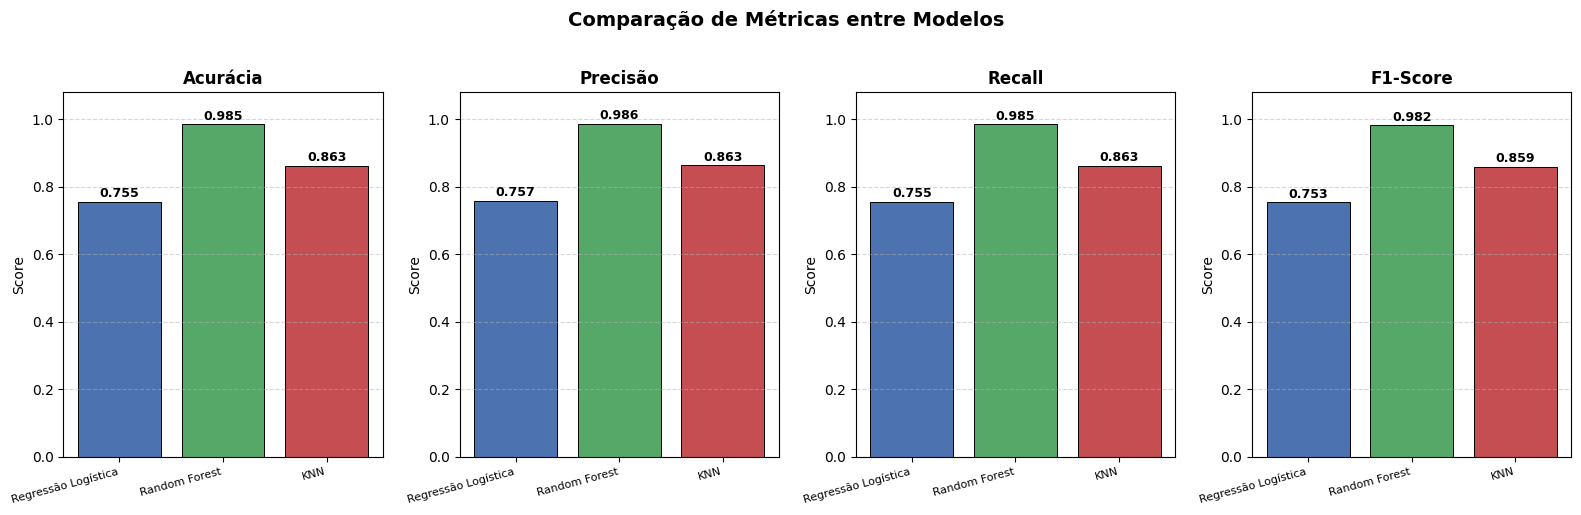

  → Figura salva: comparacao_metricas.png


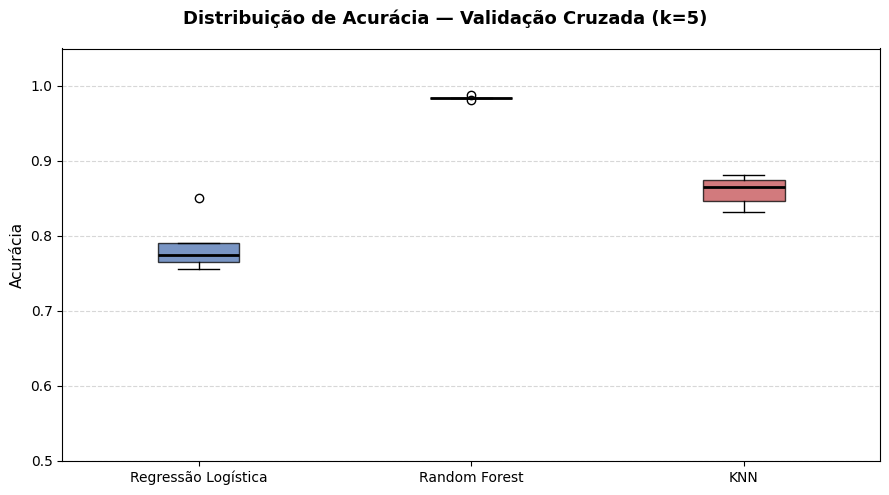

  → Figura salva: validacao_cruzada_boxplot.png


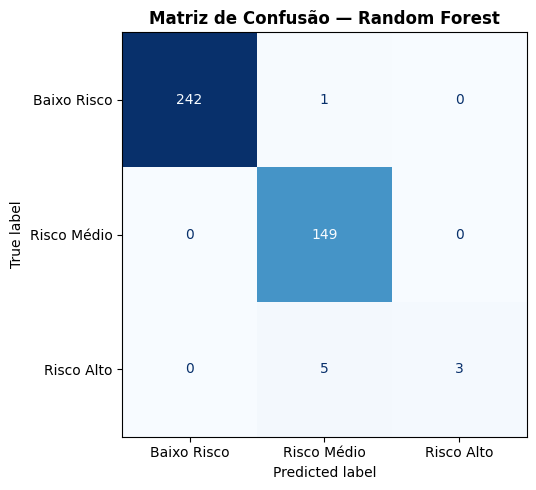

  → Figura salva: matriz_confusao.png


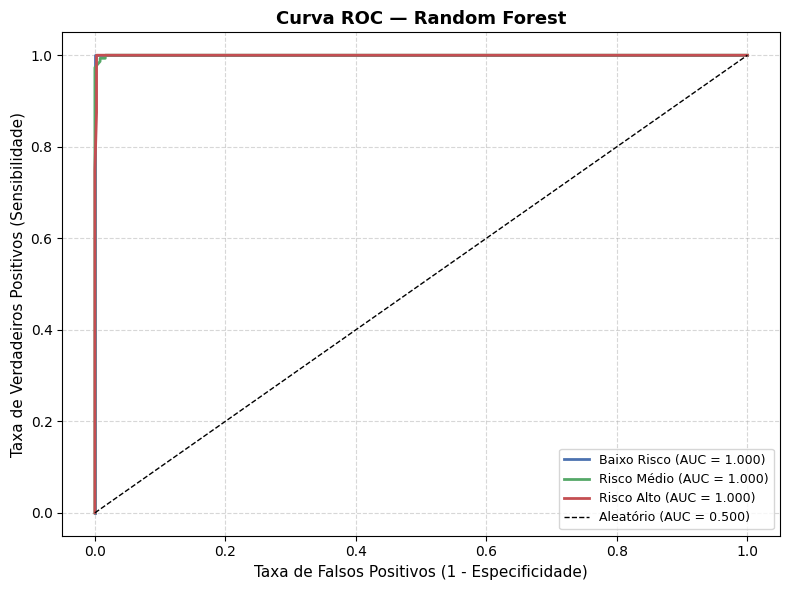

  → Figura salva: curva_roc.png

  SEÇÃO 10 — PREDIÇÃO PARA UM NOVO PACIENTE

  Paciente: Roberto
  ─────────────────────────────────────
  Idade            : 62 anos
  Glicose          : 142 mg/dL
  Pressão Arterial : 155 mmHg
  IMC              : 31.5 kg/m²
  Colesterol       : 255 mg/dL

  ─────────────────────────────────────────────────
  RESULTADO DA PREDIÇÃO (Random Forest)
  ─────────────────────────────────────────────────
  Classificação  : 🚨  RISCO ALTO
  Recomendação   : Intervenção médica urgente indicada.

  Probabilidades por classe:
    BAIXO RISCO  |                                0.0%
    RISCO MÉDIO  | █████                          19.0%
    RISCO ALTO   | ████████████████████████       81.0%

  PIPELINE CONCLUÍDO COM SUCESSO


In [7]:
# =============================================================================
# BLOCO 2 — PIPELINE COMPLETO DE MACHINE LEARNING
# Sistema de Predição de Risco Clínico
# =============================================================================
# Fluxo completo:
#   1. Leitura do dataset
#   2. Análise exploratória inicial (EDA)
#   3. Separação de features (X) e target (y)
#   4. Divisão treino / teste
#   5. Normalização (StandardScaler)
#   6. Treinamento de múltiplos modelos
#   7. Avaliação com métricas detalhadas
#   8. Validação cruzada (k-fold, k=5)
#   9. Comparação e seleção do melhor modelo
#  10. Visualizações (barras de acurácia, matriz de confusão, curva ROC)
#  11. Predição de novo paciente
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTAÇÕES
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

# Pré-processamento e particionamento de dados
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")   # Suprime avisos de convergência para exibição limpa

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 1 — LEITURA E EXPLORAÇÃO INICIAL DO DATASET
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  SEÇÃO 1 — LEITURA E EXPLORAÇÃO DO DATASET")
print("=" * 65)

# Lê o CSV gerado pelo script anterior
df = pd.read_csv("pacientes.csv")

print(f"\nDimensões do dataset : {df.shape[0]} linhas × {df.shape[1]} colunas")
print("\n--- Tipos de dados por coluna ---")
print(df.dtypes)

print("\n--- Verificação de valores ausentes ---")
print(df.isnull().sum())   # Ideal: todos zero (dataset sintético)

print("\n--- Estatísticas descritivas das variáveis numéricas ---")
print(df.describe().round(2))

print("\n--- Distribuição da variável alvo ---")
mapeamento_risco = {0: "Baixo (0)", 1: "Médio (1)", 2: "Alto (2)"}
for nivel, grupo in df.groupby("risco"):
    print(f"  {mapeamento_risco[nivel]}: {len(grupo)} pacientes "
          f"({len(grupo)/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 2 — SEPARAÇÃO DE FEATURES E TARGET
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 2 — SEPARAÇÃO DE FEATURES (X) E TARGET (y)")
print("=" * 65)

# A coluna "nome" é identificador — não tem valor preditivo, removida de X.
# A coluna "risco" é o que queremos prever — vai para y.
FEATURES = ["idade", "glicose", "pressao_arterial", "imc", "colesterol"]
TARGET   = "risco"

X = df[FEATURES].values    # Matriz de entrada  → shape (2000, 5)
y = df[TARGET].values      # Vetor de saída     → shape (2000,)

print(f"\nFeatures selecionadas : {FEATURES}")
print(f"Shape de X            : {X.shape}")
print(f"Shape de y            : {y.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 3 — DIVISÃO TREINO / TESTE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 3 — DIVISÃO TREINO / TESTE (80% / 20%)")
print("=" * 65)

# stratify=y garante que as proporções das classes sejam mantidas
# em ambos os conjuntos — essencial para datasets desbalanceados.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% dos dados para teste
    random_state=42,     # semente para reprodutibilidade
    stratify=y           # mantém proporção das classes
)

print(f"\nConjunto de treino : {X_train.shape[0]} amostras")
print(f"Conjunto de teste  : {X_test.shape[0]} amostras")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 4 — NORMALIZAÇÃO DAS FEATURES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 4 — NORMALIZAÇÃO COM StandardScaler")
print("=" * 65)

# O StandardScaler transforma cada feature para ter:
#   média = 0  e  desvio padrão = 1
# Isso é fundamental para algoritmos sensíveis à escala (LR, KNN).
# IMPORTANTE: o scaler é AJUSTADO apenas no treino e APLICADO no teste.
# Isso evita data leakage (vazamento de informação do teste para o treino).

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Ajusta e transforma o treino
X_test_scaled  = scaler.transform(X_test)        # Apenas transforma o teste

print("\nNormalização aplicada com sucesso.")
print(f"  Média das features (treino após escala)  : "
      f"{X_train_scaled.mean(axis=0).round(4)}")
print(f"  Desvio padrão (treino após escala)       : "
      f"{X_train_scaled.std(axis=0).round(4)}")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 5 — DEFINIÇÃO E TREINAMENTO DOS MODELOS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 5 — TREINAMENTO DOS MODELOS")
print("=" * 65)

# Dicionário de modelos — facilita iterar e comparar de forma organizada.
# Cada entrada: "Nome Legível" → instância do modelo configurada
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000,      # Iterações máximas para convergência
        random_state=42,
        multi_class="auto"  # Detecta automaticamente multiclasse
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,   # 100 árvores de decisão no ensemble
        random_state=42,
        n_jobs=-1           # Usa todos os núcleos disponíveis
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7,      # k=7 vizinhos (ímpar evita empate)
        metric="minkowski"  # Distância Euclidiana generalizada
    )
}

# Treina todos os modelos e armazena resultados
resultados = {}

for nome_modelo, modelo in modelos.items():
    print(f"\n  Treinando: {nome_modelo} ...", end=" ")
    modelo.fit(X_train_scaled, y_train)   # Treinamento no conjunto de treino
    print("concluído.")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 6 — AVALIAÇÃO COM MÉTRICAS DETALHADAS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 6 — AVALIAÇÃO DOS MODELOS (CONJUNTO DE TESTE)")
print("=" * 65)

# Estrutura para guardar métricas de cada modelo
metricas_df_linhas = []

for nome_modelo, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)   # Predição no conjunto de teste

    # Métricas individuais
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # Armazena para comparação posterior
    resultados[nome_modelo] = {
        "modelo"   : modelo,
        "y_pred"   : y_pred,
        "acuracia" : acc,
        "precisao" : prec,
        "recall"   : rec,
        "f1_score" : f1
    }

    metricas_df_linhas.append({
        "Modelo"   : nome_modelo,
        "Acurácia" : round(acc,  4),
        "Precisão" : round(prec, 4),
        "Recall"   : round(rec,  4),
        "F1-Score" : round(f1,   4)
    })

    # Relatório completo por classe
    print(f"\n{'─'*55}")
    print(f"  {nome_modelo}")
    print(f"{'─'*55}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Baixo Risco", "Risco Médio", "Risco Alto"],
        zero_division=0
    ))

# Tabela resumo de métricas
metricas_df = pd.DataFrame(metricas_df_linhas).set_index("Modelo")
print("\n--- TABELA COMPARATIVA DE MÉTRICAS ---")
print(metricas_df.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 7 — VALIDAÇÃO CRUZADA (K-FOLD, k=5)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 7 — VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5)")
print("=" * 65)
print("""
  A validação cruzada divide o treino em k=5 partes (folds).
  O modelo é treinado em 4 partes e testado na 5ª, repetindo 5 vezes.
  Isso fornece uma estimativa mais robusta e confiável do desempenho.
""")

# StratifiedKFold mantém a proporção das classes em cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = {}
for nome_modelo, modelo in modelos.items():
    scores = cross_val_score(
        modelo, X_train_scaled, y_train,
        cv=skf,
        scoring="accuracy",
        n_jobs=-1
    )
    cv_resultados[nome_modelo] = scores
    print(f"\n  {nome_modelo}")
    print(f"    Scores por fold : {scores.round(4)}")
    print(f"    Média           : {scores.mean():.4f}")
    print(f"    Desvio padrão   : {scores.std():.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 8 — SELEÇÃO DO MELHOR MODELO
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 8 — SELEÇÃO DO MELHOR MODELO")
print("=" * 65)

# Critério: maior média de F1-Score (equilíbrio entre precisão e recall)
melhor_nome   = max(resultados, key=lambda m: resultados[m]["f1_score"])
melhor_modelo = resultados[melhor_nome]["modelo"]
melhor_pred   = resultados[melhor_nome]["y_pred"]

print(f"\n  ✅ Melhor modelo selecionado: {melhor_nome}")
print(f"     Acurácia  : {resultados[melhor_nome]['acuracia']:.4f}")
print(f"     F1-Score  : {resultados[melhor_nome]['f1_score']:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 9 — VISUALIZAÇÕES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 9 — GERANDO VISUALIZAÇÕES")
print("=" * 65)

# Paleta de cores para os modelos
CORES = {
    "Regressão Logística": "#4C72B0",
    "Random Forest"      : "#55A868",
    "KNN"                : "#C44E52"
}

# ── Figura 1: Comparação de métricas entre modelos ───────────────────────────
fig1, axes = plt.subplots(1, 4, figsize=(16, 5))
fig1.suptitle("Comparação de Métricas entre Modelos", fontsize=14, fontweight="bold", y=1.02)

metricas_nomes = ["Acurácia", "Precisão", "Recall", "F1-Score"]
metricas_keys  = ["acuracia", "precisao", "recall", "f1_score"]

for ax, metrica_nome, metrica_key in zip(axes, metricas_nomes, metricas_keys):
    nomes_modelos = list(resultados.keys())
    valores       = [resultados[m][metrica_key] for m in nomes_modelos]
    cores_barras  = [CORES[m] for m in nomes_modelos]

    barras = ax.bar(nomes_modelos, valores, color=cores_barras, edgecolor="black",
                    linewidth=0.7)

    # Rótulo com o valor em cima de cada barra
    for barra, val in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title(metrica_nome, fontweight="bold")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_xticks(range(len(nomes_modelos)))
    ax.set_xticklabels(nomes_modelos, rotation=15, ha="right", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("comparacao_metricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Figura salva: comparacao_metricas.png")

# ── Figura 2: Comparação de Validação Cruzada (boxplot) ──────────────────────
fig2, ax = plt.subplots(figsize=(9, 5))
fig2.suptitle("Distribuição de Acurácia — Validação Cruzada (k=5)",
              fontsize=13, fontweight="bold")

dados_cv    = list(cv_resultados.values())
nomes_cv    = list(cv_resultados.keys())
bp = ax.boxplot(dados_cv, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))

for patch, nome in zip(bp["boxes"], nomes_cv):
    patch.set_facecolor(CORES[nome])
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(nomes_cv) + 1))
ax.set_xticklabels(nomes_cv, fontsize=10)
ax.set_ylabel("Acurácia", fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("validacao_cruzada_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Figura salva: validacao_cruzada_boxplot.png")

# ── Figura 3: Matriz de Confusão do Melhor Modelo ────────────────────────────
fig3, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, melhor_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Baixo Risco", "Risco Médio", "Risco Alto"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de Confusão — {melhor_nome}", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Figura salva: matriz_confusao.png")

# ── Figura 4: Curva ROC (One-vs-Rest para multiclasse) ───────────────────────
# A curva ROC mede a relação entre sensibilidade (recall) e especificidade
# para cada classe. Em multiclasse, usamos a estratégia One-vs-Rest (OvR).
CLASSES   = [0, 1, 2]
ROTULOS   = ["Baixo Risco", "Risco Médio", "Risco Alto"]
CORES_ROC = ["#4C72B0", "#55A868", "#C44E52"]

# Binariza y_test no formato One-vs-Rest para cálculo do ROC
y_test_bin = label_binarize(y_test, classes=CLASSES)

# predict_proba retorna probabilidade para cada classe — necessário para ROC
if hasattr(melhor_modelo, "predict_proba"):
    y_prob = melhor_modelo.predict_proba(X_test_scaled)

    fig4, ax = plt.subplots(figsize=(8, 6))
    for i, (rotulo, cor) in enumerate(zip(ROTULOS, CORES_ROC)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=cor, linewidth=2,
                label=f"{rotulo} (AUC = {roc_auc:.3f})")

    # Linha de referência (classificador aleatório)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatório (AUC = 0.500)")
    ax.set_xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontsize=11)
    ax.set_ylabel("Taxa de Verdadeiros Positivos (Sensibilidade)", fontsize=11)
    ax.set_title(f"Curva ROC — {melhor_nome}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  → Figura salva: curva_roc.png")
else:
    print("  (Curva ROC não disponível para este modelo — sem predict_proba)")

# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 10 — PREDIÇÃO DE NOVO PACIENTE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SEÇÃO 10 — PREDIÇÃO PARA UM NOVO PACIENTE")
print("=" * 65)

# ── Dados do paciente fictício para predição ──────────────────────────────────
# Simula um paciente com valores alterados para demonstrar classificação
novo_paciente = {
    "nome"            : "Roberto",
    "idade"           : 62,
    "glicose"         : 142,    # Acima de 126 → zona diabética
    "pressao_arterial": 155,    # Hipertensão estágio 2 (≥140)
    "imc"             : 31.5,   # Obesidade classe I (≥30)
    "colesterol"      : 255     # Colesterol alto (≥240)
}

print(f"\n  Paciente: {novo_paciente['nome']}")
print(f"  ─────────────────────────────────────")
print(f"  Idade            : {novo_paciente['idade']} anos")
print(f"  Glicose          : {novo_paciente['glicose']} mg/dL")
print(f"  Pressão Arterial : {novo_paciente['pressao_arterial']} mmHg")
print(f"  IMC              : {novo_paciente['imc']} kg/m²")
print(f"  Colesterol       : {novo_paciente['colesterol']} mg/dL")

# Converte para array no formato esperado pelo scaler (1 linha, 5 colunas)
valores_novo = np.array([[
    novo_paciente["idade"],
    novo_paciente["glicose"],
    novo_paciente["pressao_arterial"],
    novo_paciente["imc"],
    novo_paciente["colesterol"]
]])

# Aplica a MESMA normalização usada no treino (usando o scaler já ajustado)
valores_novo_scaled = scaler.transform(valores_novo)

# Realiza a predição de classe
classe_predita = melhor_modelo.predict(valores_novo_scaled)[0]

# Obtém probabilidades por classe (se disponível)
if hasattr(melhor_modelo, "predict_proba"):
    probabilidades = melhor_modelo.predict_proba(valores_novo_scaled)[0]
else:
    probabilidades = None

# Mapeamento da classe predita para rótulo legível
rotulos_risco = {
    0: ("BAIXO RISCO",   "✅", "Sem intervenção imediata necessária."),
    1: ("RISCO MÉDIO",   "⚠️",  "Recomenda-se acompanhamento clínico."),
    2: ("RISCO ALTO",    "🚨", "Intervenção médica urgente indicada.")
}
rotulo, icone, recomendacao = rotulos_risco[classe_predita]

print(f"\n  ─────────────────────────────────────────────────")
print(f"  RESULTADO DA PREDIÇÃO ({melhor_nome})")
print(f"  ─────────────────────────────────────────────────")
print(f"  Classificação  : {icone}  {rotulo}")
print(f"  Recomendação   : {recomendacao}")

if probabilidades is not None:
    print(f"\n  Probabilidades por classe:")
    for i, prob in enumerate(probabilidades):
        r_label = rotulos_risco[i][0]
        barra   = "█" * int(prob * 30)
        print(f"    {r_label:12s} | {barra:<30s} {prob*100:.1f}%")

print("\n" + "=" * 65)
print("  PIPELINE CONCLUÍDO COM SUCESSO")
print("=" * 65)